SALES PREDICTION MODEL 

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('advertising.csv')
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [5]:
df.shape

(200, 4)

In [11]:
df.isnull().sum()
df.info()
df.describe()
df.drop_duplicates(inplace=True)
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


(200, 4)

EDA : EXPLORATORY DATA ANALYSIS

<Axes: xlabel='TV', ylabel='Sales'>

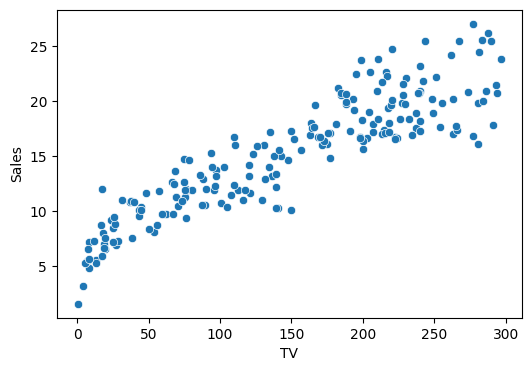

In [12]:
plt.figure(figsize=(6,4))
sns.scatterplot(x="TV",y="Sales",data=df)

In [ ]:
#The graph shows a positive correlation between TV advertising and sales. 

<Axes: xlabel='Radio', ylabel='Sales'>

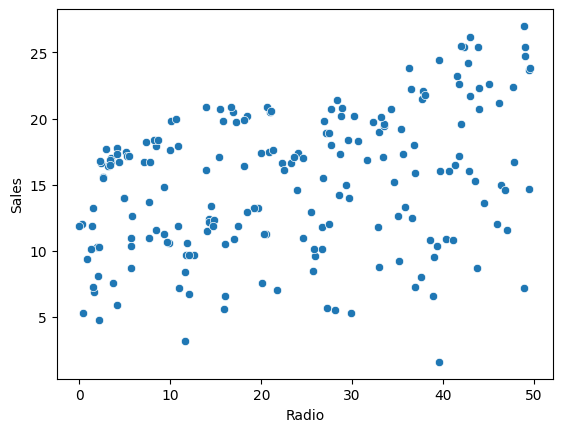

In [13]:
sns.scatterplot(x="Radio",y="Sales",data=df)

In [ ]:
# The graph shows a positive correlation between Radio advertising and sales, but it is not as strong as the correlation between TV advertising and sales.

<Axes: xlabel='Newspaper', ylabel='Sales'>

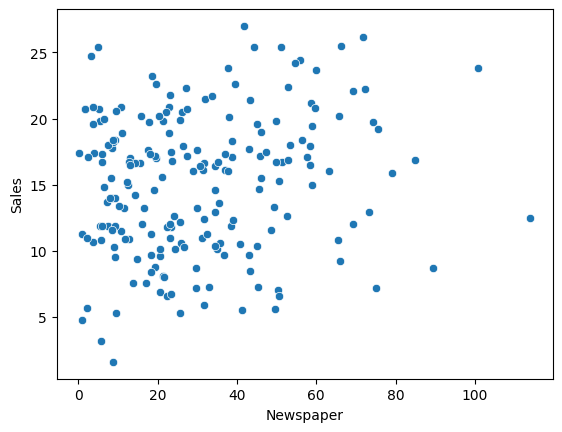

In [14]:
sns.scatterplot(x='Newspaper',y='Sales',data=df)

In [ ]:
# The graph shows little to no correlation between Newspaper asdvertising and sales. 

Data preprocessing

In [17]:
# There is no string value in the dataset, so we do not have to do any encoding.

X = df.drop('Sales',axis=1)
y = df['Sales']

from sklearn.model_selection import train_test_split
X_train,X_test,y_train,Y_test = train_test_split(X,y,test_size=0.2,random_state=42)

from sklearn.preprocessing import StandardScaler 
scaler = StandardScaler()
X_trainscaled = scaler.fit_transform(X_train)
X_testscaled = scaler.transform(X_test)

Model Training

In [18]:
from sklearn.linear_model import LinearRegression 

model = LinearRegression()
model.fit(X_trainscaled,y_train)

y_pred = model.predict(X_testscaled)

In [19]:
y_pred

array([17.0347724 , 20.40974033, 23.72398873,  9.27278518, 21.68271879,
       12.56940161, 21.08119452,  8.69035045, 17.23701254, 16.66657475,
        8.92396497,  8.4817344 , 18.2075123 ,  8.06750728, 12.64550975,
       14.93162809,  8.12814594, 17.89876565, 11.00880637, 20.47832788,
       20.80631846, 12.59883297, 10.9051829 , 22.38854775,  9.41796094,
        7.92506736, 20.83908497, 13.81520938, 10.77080925,  7.92682509,
       15.95947357, 10.63490851, 20.80292008, 10.43434164, 21.5784752 ,
       21.18364487, 12.12821771, 22.80953262, 12.60992766,  6.46441252])

Model Evaluation

In [23]:
from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(Y_test, y_pred)
r2 = r2_score(Y_test, y_pred)
print("Mean Squared Error:", mse)
print("R-squared:", r2)

Mean Squared Error: 2.9077569102710923
R-squared: 0.9059011844150826


In [ ]:
print("-----Enter Details to Predict sales-----")
tv = float(input("Enter TV advertising budget: "))
radio = float(input("Enter Radio advertising budget: "))
newspaper = float(input("Enter Newspaper advertising budget: "))

user_df = pd.DataFrame(0, index=[0], columns=X.columns)
user_df['TV'] = tv
user_df['Radio'] = radio
user_df['Newspaper'] = newspaper

user_scaled = scaler.transform(user_df)
predicted_sales = model.predict(user_scaled)
print(f"Predicted Sales: {predicted_sales[0]:.2f}")



-----Enter Details to Predict sales-----
Predicted Sales: 20.66
